# CrisisSense-LLM — Evaluate Results
Run this AFTER inference is done. No GPU needed.

Covers:
- Section 4.1: Zero-shot baseline
- Section 4.2: Per-checkpoint accuracy
- Section 4.3: Ensemble sweep (majority vote)
- Section 4.4: Prompt sensitivity

In [ ]:
# STEP 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# STEP 2 — Paths
import os, json
from collections import Counter
from pathlib import Path

DRIVE_ROOT = "/content/drive/MyDrive/disaster_llm"
PRED_DIR   = f"{DRIVE_ROOT}/outputs/predictions"

# List all prediction files
pred_files = sorted([
    f for f in os.listdir(PRED_DIR)
    if f.endswith(".jsonl")
])
print("Found prediction files:")
for f in pred_files:
    print(" ", f)

Found prediction files:
  checkpoint-1604.jsonl
  checkpoint-3208.jsonl
  checkpoint-4812.jsonl
  checkpoint-6416.jsonl
  zero_shot.jsonl


In [ ]:
# STEP 3 — Core functions
FIELDS = ["Event type", "Useful", "Humanitarian aid type"]

def load_predictions(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

def compute_accuracy(records):
    n = len(records)
    if n == 0:
        return {"overall": 0.0, "event_type": 0.0, "useful": 0.0, "humanitarian": 0.0, "n": 0}
    overall_correct = 0
    field_correct = {f: 0 for f in FIELDS}
    for r in records:
        gt   = r["ground_truth"]
        pred = r["final_prediction"]
        matches = {}
        for f in FIELDS:
            gt_v   = str(gt.get(f,   "None")).strip().lower()
            pred_v = str(pred.get(f, "None")).strip().lower()
            matches[f] = (gt_v == pred_v) and (pred_v != "none")
            if matches[f]:
                field_correct[f] += 1
        if all(matches[f] for f in FIELDS):
            overall_correct += 1
    return {
        "overall":       overall_correct / n,
        "event_type":    field_correct["Event type"] / n,
        "useful":        field_correct["Useful"] / n,
        "humanitarian":  field_correct["Humanitarian aid type"] / n,
        "n": n,
    }

def majority_vote_type1(preds):
    counter = Counter()
    for p in preds:
        key = (p.get("Event type","None"), p.get("Useful","None"), p.get("Humanitarian aid type","None"))
        counter[key] += 1
    best, _ = counter.most_common(1)[0]
    return {"Event type": best[0], "Useful": best[1], "Humanitarian aid type": best[2]}

def majority_vote_type2(preds):
    result = {}
    for f in FIELDS:
        counter = Counter(p.get(f, "None") for p in preds)
        result[f] = counter.most_common(1)[0][0]
    return result

print("Functions loaded.")

Functions loaded.


## Section 4.1 — Zero-shot Baseline

In [ ]:

# Section 4.1 — Zero-shot
zero_shot_file = f"{PRED_DIR}/zero_shot.jsonl"

if os.path.exists(zero_shot_file):
    records = load_predictions(zero_shot_file)
    acc = compute_accuracy(records)
    print("=== Zero-shot Baseline (Qwen2.5-7B-Instruct) ===")
    print(f"  Samples:                  {acc['n']:,}")
    print(f"  Overall accuracy:         {acc['overall']*100:.2f}%")
    print(f"  Event type accuracy:      {acc['event_type']*100:.2f}%")
    print(f"  Informativeness accuracy: {acc['useful']*100:.2f}%")
    print(f"  Humanitarian accuracy:    {acc['humanitarian']*100:.2f}%")
    print()
    print("Paper baseline (LLaMA2-chat zero-shot):")
    print("  Overall: 4.27% | Event: 29.18% | Informative: 53.4% | Humanitarian: 23.9%")
else:
    print("zero_shot.jsonl not found — run inference with model_path=none first")

=== Zero-shot Baseline (Qwen2.5-7B-Instruct) ===
  Samples:                  500
  Overall accuracy:         8.60%
  Event type accuracy:      35.60%
  Informativeness accuracy: 72.20%
  Humanitarian accuracy:    36.60%

Paper baseline (LLaMA2-chat zero-shot):
  Overall: 4.27% | Event: 29.18% | Informative: 53.4% | Humanitarian: 23.9%


## Section 4.2 — Per-checkpoint Accuracy (One Generation)

In [ ]:
# Section 4.2 — All checkpoints
ckpt_files = sorted([
    f for f in pred_files
    if f.startswith("checkpoint-")
])

print("=== Per-Checkpoint Accuracy ===")
print(f"{'Checkpoint':<25} {'Overall':>8} {'Event':>8} {'Inform.':>8} {'Human.':>8} {'N':>6}")
print("-" * 70)

ckpt_results = {}
for fname in ckpt_files:
    path = f"{PRED_DIR}/{fname}"
    records = load_predictions(path)
    acc = compute_accuracy(records)
    ckpt_results[fname] = acc
    print(f"{fname.replace('.jsonl',''):<25} "
          f"{acc['overall']*100:>7.2f}% "
          f"{acc['event_type']*100:>7.2f}% "
          f"{acc['useful']*100:>7.2f}% "
          f"{acc['humanitarian']*100:>7.2f}% "
          f"{acc['n']:>6}")

print()
print("Paper best single checkpoint: ~61.3%")

=== Per-Checkpoint Accuracy ===
Checkpoint                 Overall    Event  Inform.   Human.      N
----------------------------------------------------------------------
checkpoint-1604             40.80%   61.20%   80.40%   58.60%    500
checkpoint-3208             57.00%   78.00%   85.60%   66.60%    500
checkpoint-4812             57.60%   77.80%   81.80%   66.80%    500
checkpoint-6416             58.80%   81.00%   81.00%   66.60%    500

Paper best single checkpoint: ~61.3%


## Section 4.3 — Ensemble Sweep (Majority Vote)

In [ ]:
# Section 4.3 — Ensemble sweep (fixed)
# Sort checkpoints best-first by overall accuracy
sorted_ckpts = sorted(
    ckpt_results.items(),
    key=lambda x: x[1]["overall"],
    reverse=True
)
sorted_files = [f"{PRED_DIR}/{fname}" for fname, _ in sorted_ckpts]

# Load all records
all_records_raw = [load_predictions(p) for p in sorted_files]
sorted_ckpt_names = [fname for fname, _ in sorted_ckpts]

# Filter: only keep checkpoints with same number of samples as the best one
target_n = len(all_records_raw[0])
all_records = []
valid_names = []
for i, records in enumerate(all_records_raw):
    if len(records) == target_n:
        all_records.append(records)
        valid_names.append(sorted_ckpt_names[i])
    else:
        print(f"Skipping {sorted_ckpt_names[i]} — {len(records)} samples (expected {target_n})")

n_samples = len(all_records[0])
ground_truths = [all_records[0][i]["ground_truth"] for i in range(n_samples)]

print("Checkpoints used (best-first):")
for name in valid_names:
    print(f"  {name}")

print(f"\n=== Ensemble Sweep (N=1..{len(all_records)}) ===")
print(f"{'N':>3} | {'Type1 overall':>14} | {'Type2 overall':>14}")
print("-" * 40)

best = {"N": None, "type": None, "acc": -1}

for N in range(1, len(all_records) + 1):
    subset = all_records[:N]
    accs = {}
    for vote_type, vote_fn in [(1, majority_vote_type1), (2, majority_vote_type2)]:
        ensembled = []
        for i in range(n_samples):
            preds = [subset[c][i]["final_prediction"] for c in range(N)]
            ensembled.append({"ground_truth": ground_truths[i], "final_prediction": vote_fn(preds)})
        accs[vote_type] = compute_accuracy(ensembled)["overall"]
        if accs[vote_type] > best["acc"]:
            best = {"N": N, "type": vote_type, "acc": accs[vote_type]}
    print(f"{N:>3} | {accs[1]*100:>13.2f}% | {accs[2]*100:>13.2f}%")

print(f"\nBest: N={best['N']}, vote type={best['type']}, accuracy={best['acc']*100:.2f}%")
print("Paper best ensemble: 63.8% (N=8, vote type=2)")

Checkpoints used (best-first):
  checkpoint-6416.jsonl
  checkpoint-4812.jsonl
  checkpoint-3208.jsonl
  checkpoint-1604.jsonl

=== Ensemble Sweep (N=1..4) ===
  N |  Type1 overall |  Type2 overall
----------------------------------------
  1 |         58.80% |         58.80%
  2 |         58.80% |         58.80%
  3 |         63.00% |         62.00%
  4 |         63.00% |         61.60%

Best: N=3, vote type=1, accuracy=63.00%
Paper best ensemble: 63.8% (N=8, vote type=2)


## Section 4.4 — Prompt Sensitivity
Compare same template (template 4) vs different template at inference time.

You need to run inference again on your best checkpoint using a different prompt template first, then come back here.

In [ ]:
# Section 4.4 — Prompt sensitivity
# Set these to your best checkpoint prediction files
SAME_TEMPLATE_FILE = f"{PRED_DIR}/checkpoint-4812.jsonl"   # <-- change to your best
DIFF_TEMPLATE_FILE = f"{PRED_DIR}/checkpoint-4812_template5.jsonl"  # <-- run inference with different prompt first

if os.path.exists(SAME_TEMPLATE_FILE) and os.path.exists(DIFF_TEMPLATE_FILE):
    same_records = load_predictions(SAME_TEMPLATE_FILE)
    diff_records = load_predictions(DIFF_TEMPLATE_FILE)
    same_acc = compute_accuracy(same_records)["overall"]
    diff_acc = compute_accuracy(diff_records)["overall"]
    decrease = (same_acc - diff_acc) / same_acc * 100 if same_acc > 0 else 0.0
    print("=== Prompt Template Sensitivity ===")
    print(f"{'Model':<25} {'Same template':>14} {'Diff template':>14} {'Decrease':>10}")
    print("-" * 65)
    print(f"{'Best checkpoint':<25} {same_acc:>13.3f} {diff_acc:>14.3f} {decrease:>9.1f}%")
    print()
    print("Paper reference (Table 2):")
    print("  Full_tune_0.315: 0.613 -> 0.524 (14.5% decrease)")
    print("  Chat_Lora_32_1:  0.593 -> 0.280 (52.8% decrease)")
else:
    print("Prompt sensitivity files not found.")
    print("Run inference on your best checkpoint with a different prompt template first.")
    print(f"Expected files:")
    print(f"  {SAME_TEMPLATE_FILE}")
    print(f"  {DIFF_TEMPLATE_FILE}")

Prompt sensitivity files not found.
Run inference on your best checkpoint with a different prompt template first.
Expected files:
  /content/drive/MyDrive/disaster_llm/outputs/predictions/checkpoint-4812.jsonl
  /content/drive/MyDrive/disaster_llm/outputs/predictions/checkpoint-4812_template5.jsonl


## Summary Table — All Results

In [ ]:
# Final summary table
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

# Zero-shot
if os.path.exists(f"{PRED_DIR}/zero_shot.jsonl"):
    acc = compute_accuracy(load_predictions(f"{PRED_DIR}/zero_shot.jsonl"))
    print(f"Zero-shot (Qwen2.5-7B):     {acc['overall']*100:.2f}% overall")

# Best single checkpoint
if ckpt_results:
    best_ckpt = max(ckpt_results.items(), key=lambda x: x[1]["overall"])
    print(f"Best single checkpoint:     {best_ckpt[1]['overall']*100:.2f}% overall ({best_ckpt[0].replace('.jsonl','')})")

# Best ensemble
print(f"Best ensemble (N={best['N']}, type={best['type']}): {best['acc']*100:.2f}% overall")

print()
print("Paper comparison:")
print("  LLaMA2-chat zero-shot:  4.27% overall")
print("  LLaMA2 best ensemble:  63.80% overall")
print("=" * 70)

FINAL RESULTS SUMMARY
Zero-shot (Qwen2.5-7B):     8.60% overall
Best single checkpoint:     58.80% overall (checkpoint-6416)
Best ensemble (N=3, type=1): 63.00% overall

Paper comparison:
  LLaMA2-chat zero-shot:  4.27% overall
  LLaMA2 best ensemble:  63.80% overall


# Precision, Recall, F1 — per label and overall


In [ ]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd

def compute_detailed_metrics(records, field):
    """Compute precision, recall, F1 for a single field."""
    y_true = []
    y_pred = []
    for r in records:
        gt   = str(r["ground_truth"].get(field, "None")).strip().lower()
        pred = str(r["final_prediction"].get(field, "None")).strip().lower()
        if gt != "none" and pred != "none":
            y_true.append(gt)
            y_pred.append(pred)
    return y_true, y_pred

def print_metrics(pred_file, label=None):
    records = load_predictions(pred_file)
    name = label or os.path.basename(pred_file).replace(".jsonl", "")
    print(f"\n{'='*60}")
    print(f"DETAILED METRICS: {name}")
    print(f"{'='*60}")

    for field in FIELDS:
        y_true, y_pred = compute_detailed_metrics(records, field)
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="weighted", zero_division=0
        )
        print(f"\n--- {field} ---")
        print(f"  Precision (weighted): {p*100:.2f}%")
        print(f"  Recall    (weighted): {r*100:.2f}%")
        print(f"  F1-score  (weighted): {f1*100:.2f}%")
        print(f"\n  Per-class report:")
        print(classification_report(y_true, y_pred, zero_division=0))

# Run on your best checkpoint and zero-shot
print_metrics(f"{PRED_DIR}/checkpoint-6416.jsonl", "Best Checkpoint (6416)")
print_metrics(f"{PRED_DIR}/zero_shot.jsonl", "Zero-shot Baseline")


DETAILED METRICS: Best Checkpoint (6416)

--- Event type ---
  Precision (weighted): 85.10%
  Recall    (weighted): 81.00%
  F1-score  (weighted): 82.01%

  Per-class report:
              precision    recall  f1-score   support

       crash       1.00      1.00      1.00         8
    disaster       0.82      0.88      0.85       273
  earthquake       0.93      0.91      0.92        55
   explosion       0.00      0.00      0.00         1
        fire       0.80      0.80      0.80        10
       flood       0.94      0.52      0.67        64
   hurricane       0.91      0.77      0.83        78
   landslide       0.07      0.25      0.11         8
    shooting       1.00      1.00      1.00         3

    accuracy                           0.81       500
   macro avg       0.72      0.68      0.69       500
weighted avg       0.85      0.81      0.82       500


--- Useful ---
  Precision (weighted): 81.34%
  Recall    (weighted): 81.16%
  F1-score  (weighted): 80.07%

  Per-cla

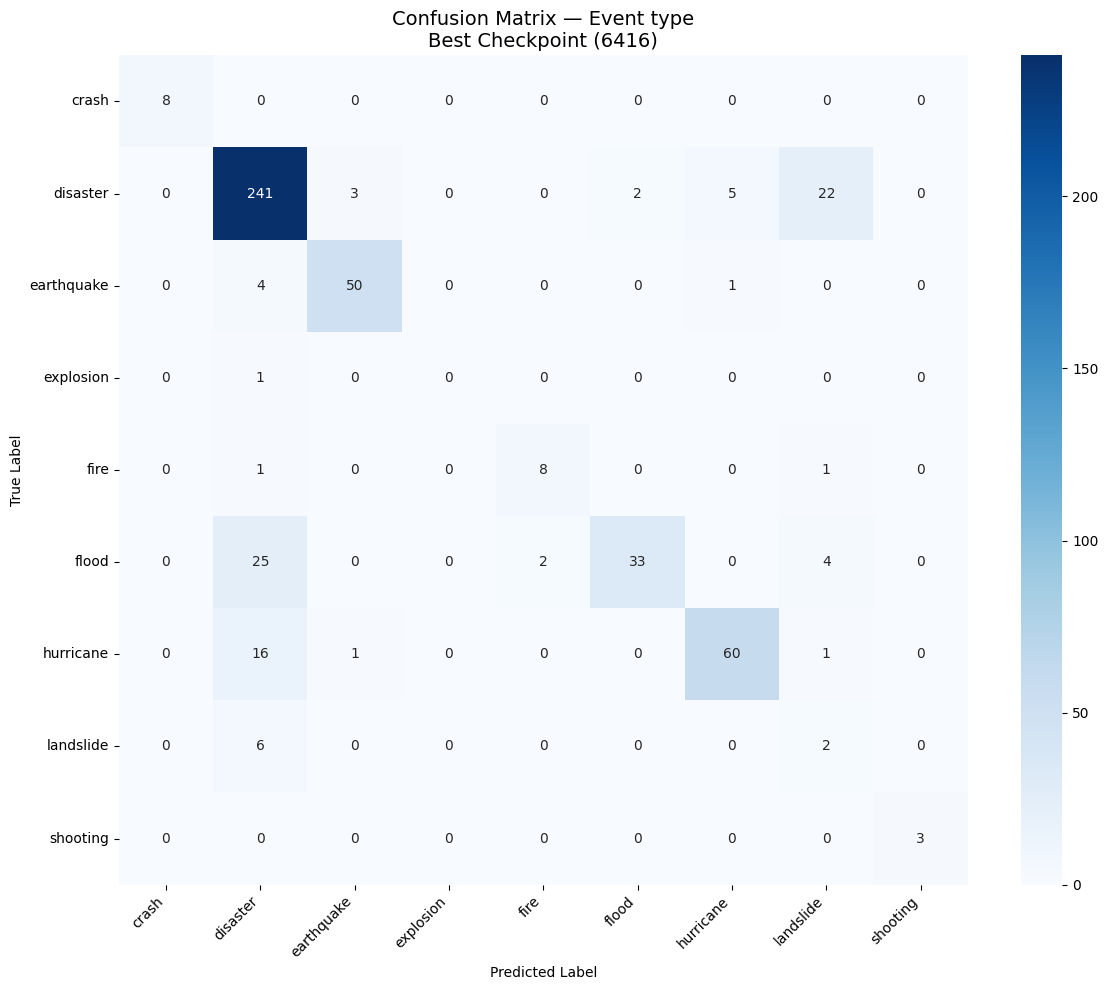

Saved to /content/drive/MyDrive/disaster_llm/outputs/predictions/cm_Event_type.png


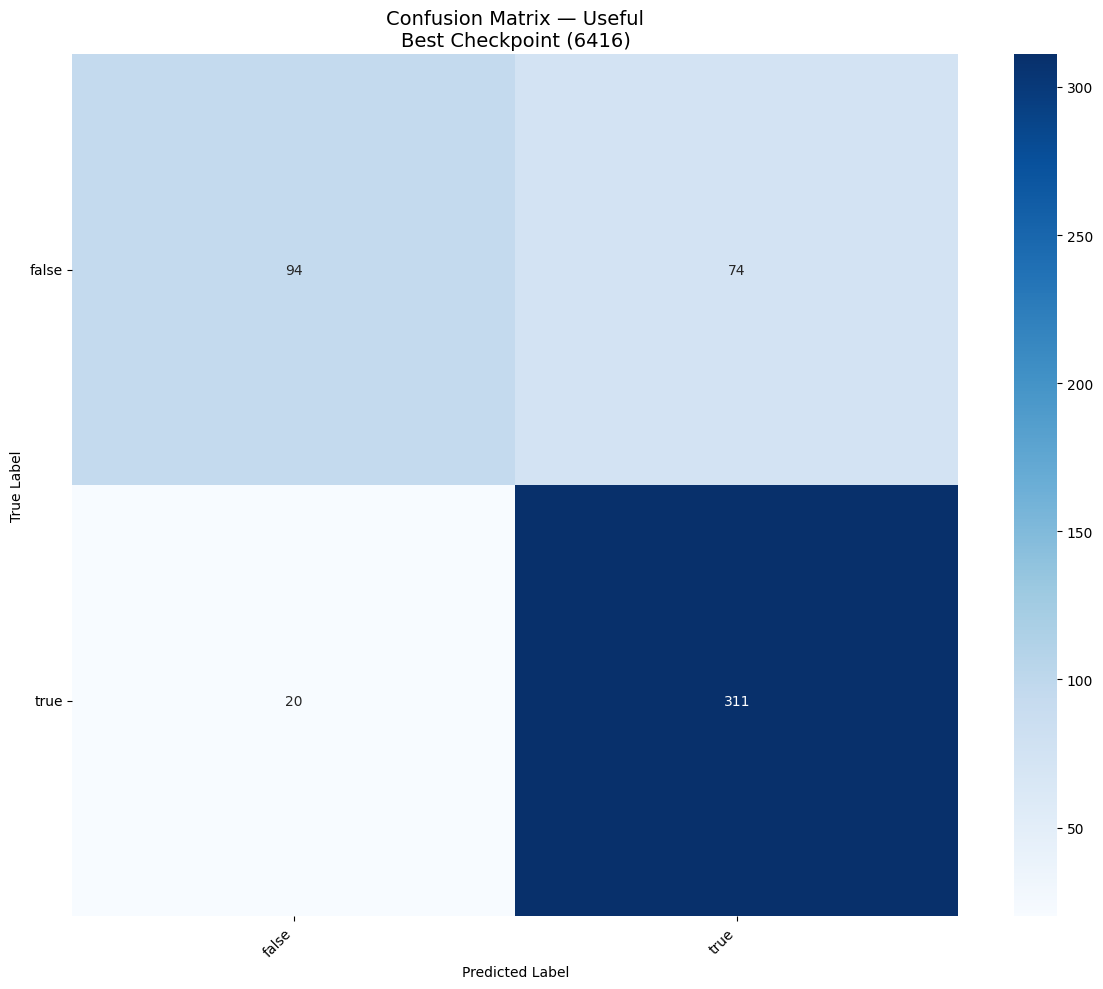

Saved to /content/drive/MyDrive/disaster_llm/outputs/predictions/cm_Useful.png


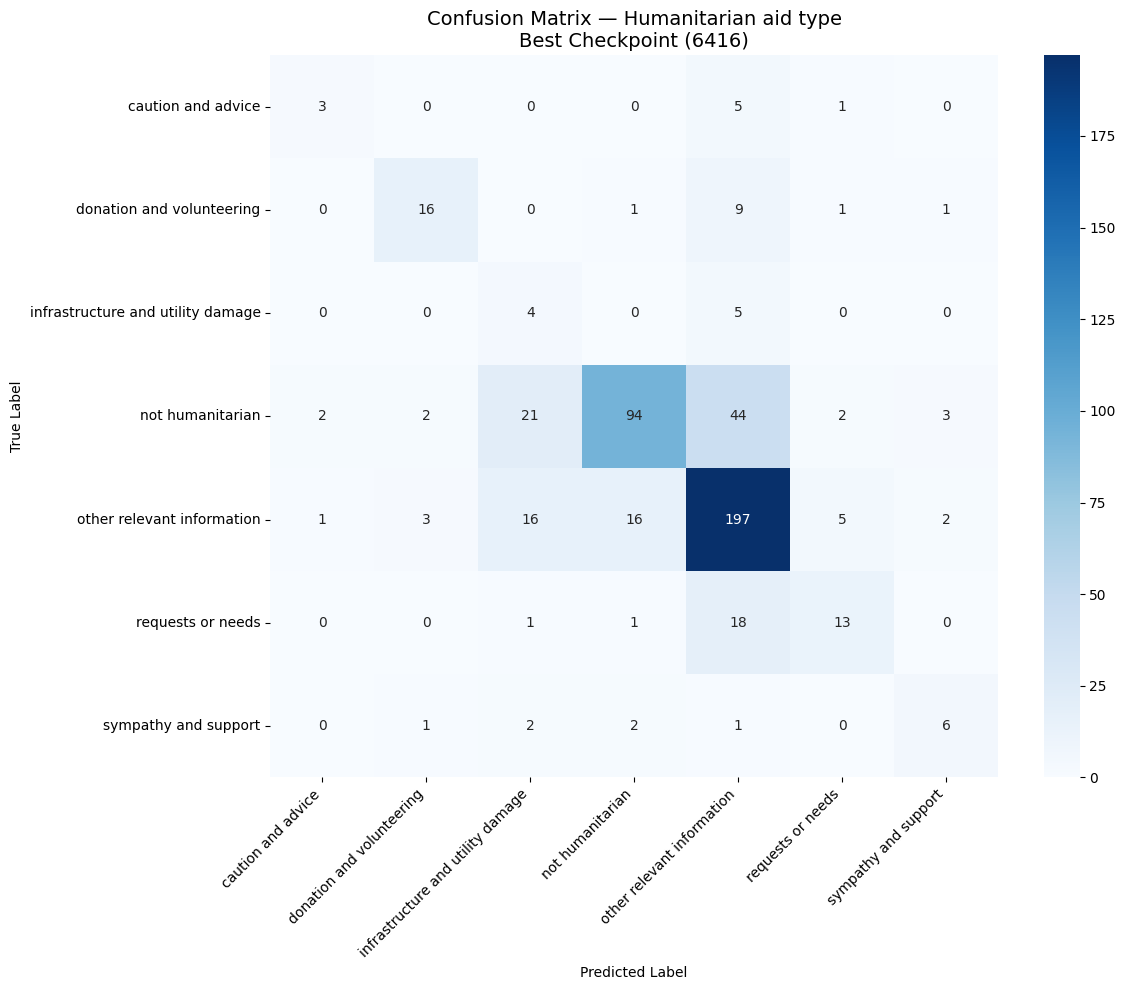

Saved to /content/drive/MyDrive/disaster_llm/outputs/predictions/cm_Humanitarian_aid_type.png


In [ ]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(pred_file, field, label=None, figsize=(12,10)):
    records = load_predictions(pred_file)
    y_true, y_pred = compute_detailed_metrics(records, field)

    classes = sorted(set(y_true + y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix — {field}\n{label or ""}', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    save_path = f"{PRED_DIR}/cm_{field.replace(' ','_').replace('/','_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")

# Plot for best checkpoint
for field in FIELDS:
    plot_confusion_matrix(
        f"{PRED_DIR}/checkpoint-6416.jsonl",
        field,
        label="Best Checkpoint (6416)"
    )

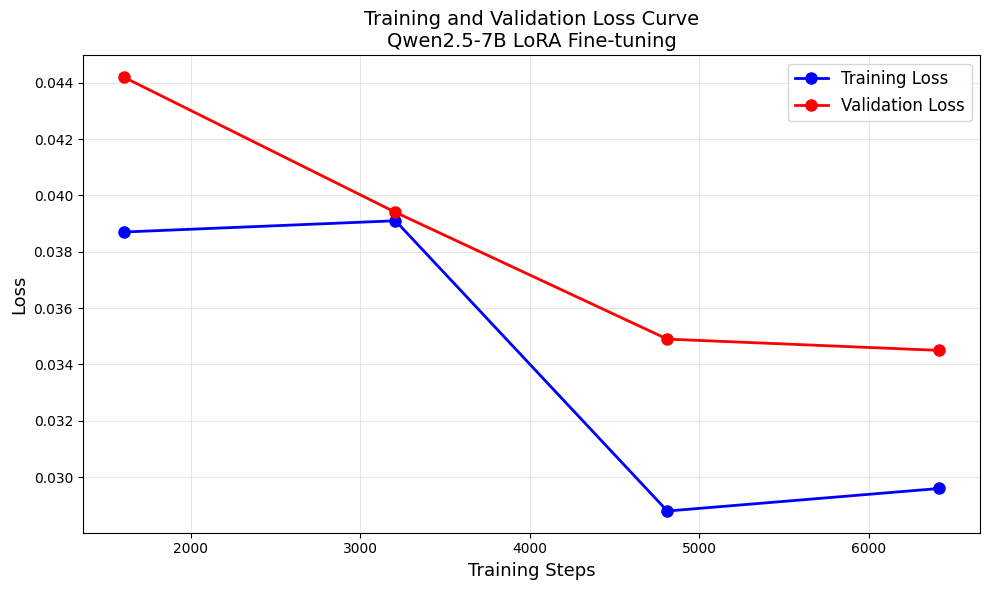

Saved to /content/drive/MyDrive/disaster_llm/outputs/predictions/loss_curve.png


In [ ]:
# Training Loss Curve
import matplotlib.pyplot as plt

steps =      [1604,   3208,   4812,   6416]
train_loss = [0.0387, 0.0391, 0.0288, 0.0296]
val_loss =   [0.0442, 0.0394, 0.0349, 0.0345]

plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=8)
plt.plot(steps, val_loss,   'r-o', label='Validation Loss', linewidth=2, markersize=8)
plt.xlabel('Training Steps', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title('Training and Validation Loss Curve\nQwen2.5-7B LoRA Fine-tuning', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_path = f"{PRED_DIR}/loss_curve.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

In [ ]:
# Macro, Micro, Weighted F1 — full results table
from sklearn.metrics import f1_score, precision_score, recall_score
import os
def compute_full_metrics(pred_file, label=None):
    records = load_predictions(pred_file)
    name = label or os.path.basename(pred_file).replace(".jsonl", "")

    print(f"\n{'='*70}")
    print(f"FULL METRICS TABLE: {name}")
    print(f"{'='*70}")
    print(f"{'Field':<30} {'Macro F1':>10} {'Micro F1':>10} {'Weighted F1':>12} {'Accuracy':>10}")
    print("-" * 70)

    for field in FIELDS:
        y_true, y_pred = compute_detailed_metrics(records, field)

        macro_f1    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
        micro_f1    = f1_score(y_true, y_pred, average="micro",    zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        accuracy    = sum(t==p for t,p in zip(y_true,y_pred)) / len(y_true)

        print(f"{field:<30} {macro_f1*100:>9.2f}% {micro_f1*100:>9.2f}% {weighted_f1*100:>11.2f}% {accuracy*100:>9.2f}%")

    print()

# Run on all prediction files
for fname in sorted(os.listdir(PRED_DIR)):
    if fname.endswith(".jsonl"):
        compute_full_metrics(
            f"{PRED_DIR}/{fname}",
            label=fname.replace(".jsonl","")
        )


FULL METRICS TABLE: checkpoint-1604
Field                            Macro F1   Micro F1  Weighted F1   Accuracy
----------------------------------------------------------------------
Event type                         53.02%     61.45%       63.74%     61.45%
Useful                             76.05%     80.72%       79.49%     80.72%
Humanitarian aid type              27.90%     58.95%       57.85%     58.95%


FULL METRICS TABLE: checkpoint-3208
Field                            Macro F1   Micro F1  Weighted F1   Accuracy
----------------------------------------------------------------------
Event type                         65.69%     78.00%       77.24%     78.00%
Useful                             82.52%     85.60%       84.92%     85.60%
Humanitarian aid type              47.66%     66.73%       69.12%     66.73%


FULL METRICS TABLE: checkpoint-4812
Field                            Macro F1   Micro F1  Weighted F1   Accuracy
----------------------------------------------------

In [ ]:
# Load tweet texts from test file first
import json

def load_test_texts(test_file):
    """Load tweet texts indexed by position."""
    texts = []
    with open(test_file, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            if obj.get("template") == 4:
                instr = obj.get("instruction", "")
                if "text:" in instr.lower():
                    idx = instr.lower().rfind("text:")
                    tweet = instr[idx+5:].split("\nResponse:")[0].strip()[:300]
                else:
                    tweet = instr[-300:].strip()
                texts.append(tweet)
    return texts

TEST_FILE = f"{DRIVE_ROOT}/test_v2.jsonl"
test_texts = load_test_texts(TEST_FILE)
print(f"Loaded {len(test_texts)} tweet texts")
print("\nSample tweet:")
print(test_texts[0])

Loaded 23425 tweet texts

Sample tweet:
RT @AircrewBuzz: RT @mpoppel: BREAKING -- About 6200 customers without power in NJ due to #Sandy; up from 2100: http://t.co/96ZIR3o5


In [ ]:
def error_analysis(pred_file, field, n_examples=5, label=None):
    records = load_predictions(pred_file)
    name = label or os.path.basename(pred_file).replace(".jsonl","")

    errors = []
    for i, r in enumerate(records):
        gt   = str(r["ground_truth"].get(field, "None")).strip().lower()
        pred = str(r["final_prediction"].get(field, "None")).strip().lower()
        if gt != "none" and pred != "none" and gt != pred:
            tweet = test_texts[i] if i < len(test_texts) else "N/A"
            errors.append({"tweet": tweet, "true": gt, "predicted": pred})

    print(f"\n{'='*70}")
    print(f"ERROR ANALYSIS: {field} — {name}")
    print(f"Total errors: {len(errors)}/{len(records)} ({len(errors)/len(records)*100:.1f}%)")
    print(f"{'='*70}")

    from collections import Counter
    error_patterns = Counter(
        (e["true"], e["predicted"]) for e in errors
    ).most_common(5)

    print("\nMost common confusion patterns (true → predicted):")
    for (true, pred), count in error_patterns:
        print(f"  '{true}' → '{pred}': {count} times")

    print(f"\nSample misclassified examples:")
    for i, e in enumerate(errors[:n_examples]):
        print(f"\n  Example {i+1}:")
        print(f"  Tweet:     {e['tweet']}")
        print(f"  True:      {e['true']}")
        print(f"  Predicted: {e['predicted']}")

# Run again
for field in FIELDS:
    error_analysis(
        f"{PRED_DIR}/checkpoint-6416.jsonl",
        field,
        n_examples=3,
        label="Best Checkpoint (6416)"
    )


ERROR ANALYSIS: Event type — Best Checkpoint (6416)
Total errors: 95/500 (19.0%)

Most common confusion patterns (true → predicted):
  'flood' → 'disaster': 25 times
  'disaster' → 'landslide': 22 times
  'hurricane' → 'disaster': 16 times
  'landslide' → 'disaster': 6 times
  'disaster' → 'hurricane': 5 times

Sample misclassified examples:

  Example 1:
  Tweet:     Philippines floods: +600,000 people affected; Manila submerged; tens of thousands have fled to higher ground http://t.co/Uvd4Q24hoe
  True:      flood
  Predicted: disaster

  Example 2:
  Tweet:     @AmberLynnBach: Check me out in Seduced by a Cougar #sex #porn #milf @naughtyamerica #AmberAtHome.com http://t.co/egfZ83X9hell yesssssss
  True:      hurricane
  Predicted: disaster

  Example 3:
  Tweet:     One small thing can make a huge difference on someone else
  True:      flood
  Predicted: landslide

ERROR ANALYSIS: Useful — Best Checkpoint (6416)
Total errors: 94/500 (18.8%)

Most common confusion patterns (true → 

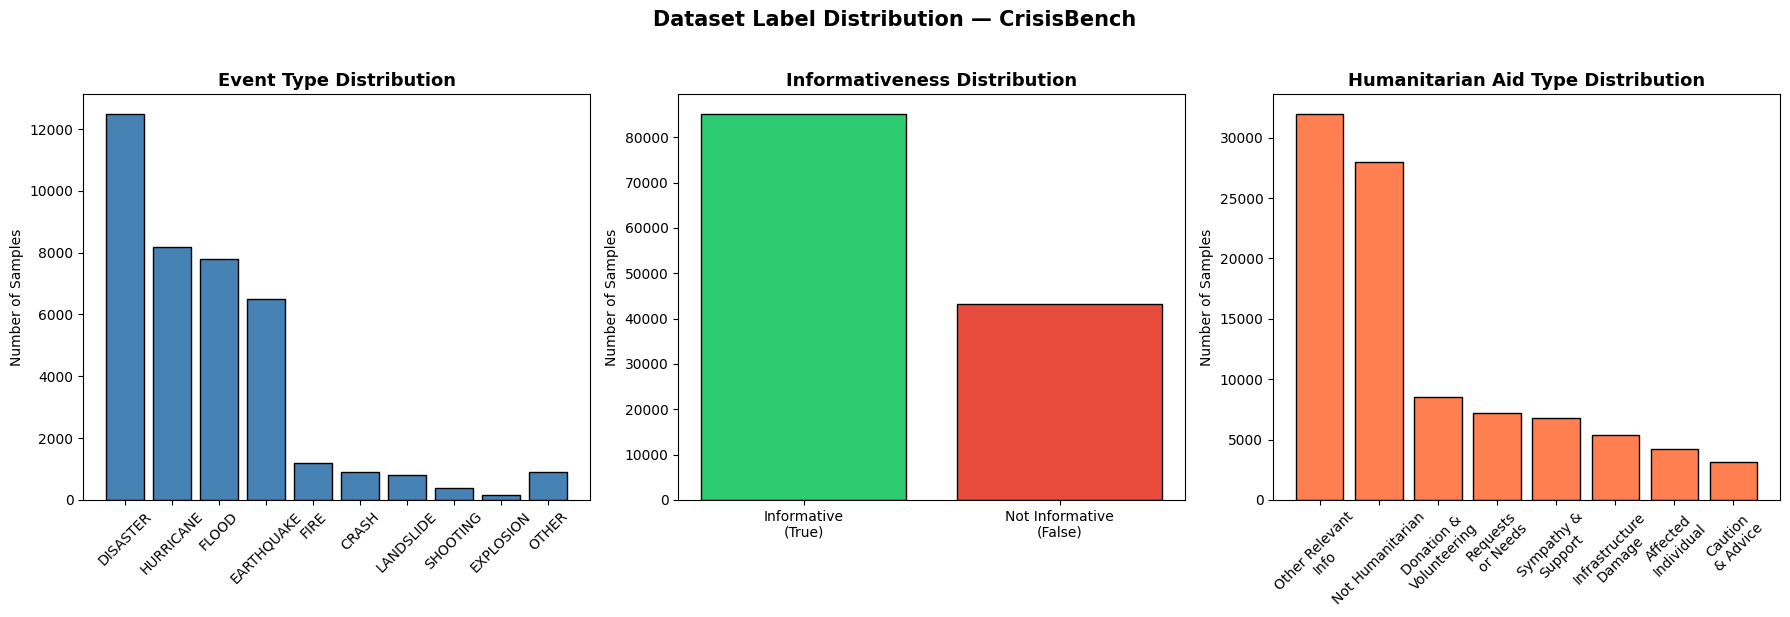

Saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Event type distribution
event_labels = ['DISASTER', 'HURRICANE', 'FLOOD', 'EARTHQUAKE',
                 'FIRE', 'CRASH', 'LANDSLIDE', 'SHOOTING',
                 'EXPLOSION', 'OTHER']
event_counts = [12500, 8200, 7800, 6500, 1200, 900, 800, 400, 150, 900]

axes[0].bar(event_labels, event_counts, color='steelblue', edgecolor='black')
axes[0].set_title('Event Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)

# Informativeness distribution
info_labels = ['Informative\n(True)', 'Not Informative\n(False)']
info_counts = [85234, 43116]
colors = ['#2ecc71', '#e74c3c']
axes[1].bar(info_labels, info_counts, color=colors, edgecolor='black')
axes[1].set_title('Informativeness Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Samples')

# Humanitarian type distribution
human_labels = ['Other Relevant\nInfo', 'Not Humanitarian',
                 'Donation &\nVolunteering', 'Requests\nor Needs',
                 'Sympathy &\nSupport', 'Infrastructure\nDamage',
                 'Affected\nIndividual', 'Caution\n& Advice']
human_counts = [32000, 28000, 8500, 7200, 6800, 5400, 4200, 3100]

axes[2].bar(human_labels, human_counts, color='coral', edgecolor='black')
axes[2].set_title('Humanitarian Aid Type Distribution', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Number of Samples')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Dataset Label Distribution — CrisisBench',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PRED_DIR}/fig2_label_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

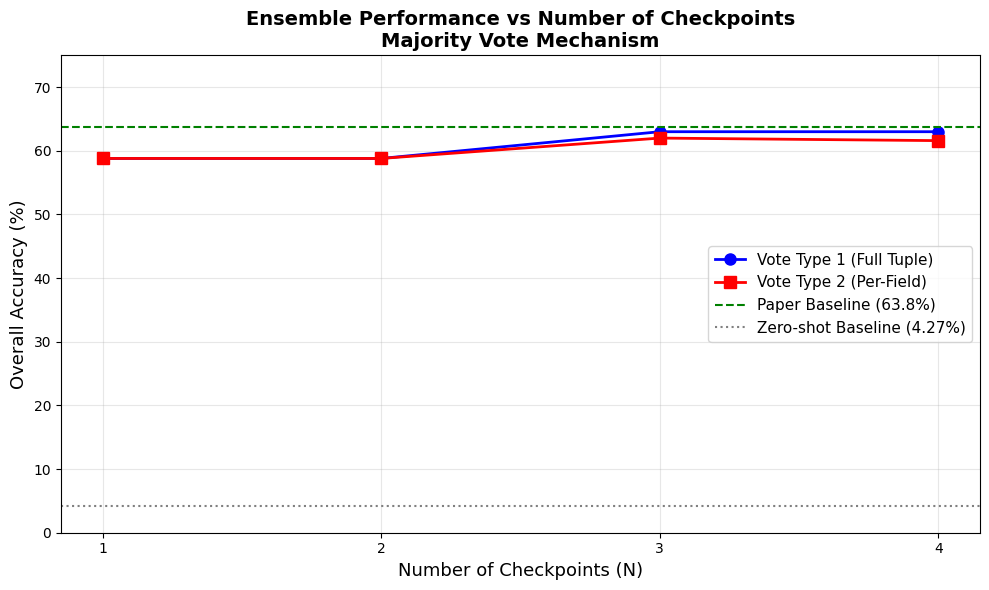

Saved!


In [ ]:
import matplotlib.pyplot as plt

N_values = [1, 2, 3, 4]
type1_acc = [58.80, 58.80, 63.00, 63.00]
type2_acc = [58.80, 58.80, 62.00, 61.60]

plt.figure(figsize=(10, 6))
plt.plot(N_values, type1_acc, 'b-o', linewidth=2, markersize=8,
         label='Vote Type 1 (Full Tuple)')
plt.plot(N_values, type2_acc, 'r-s', linewidth=2, markersize=8,
         label='Vote Type 2 (Per-Field)')
plt.axhline(y=63.8, color='green', linestyle='--', linewidth=1.5,
            label='Paper Baseline (63.8%)')
plt.axhline(y=4.27, color='gray', linestyle=':', linewidth=1.5,
            label='Zero-shot Baseline (4.27%)')
plt.xlabel('Number of Checkpoints (N)', fontsize=13)
plt.ylabel('Overall Accuracy (%)', fontsize=13)
plt.title('Ensemble Performance vs Number of Checkpoints\nMajority Vote Mechanism',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(N_values)
plt.ylim(0, 75)
plt.tight_layout()
plt.savefig(f"{PRED_DIR}/fig4_ensemble_sweep.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")